# Assignment 1, Task A: Classification problem.

## The data:
In this QSAR exercise, the mutagenicity of various molecules is to be investigated. The dataset in use is the Ames Mutagenicity Dataset for Multi-Task learning accessed via the PyTDC library, essentially as also provided here: https://huggingface.co/datasets/scikit-fingerprints/TDC_ames. Columns have been renamed for enhanced clarity.

The dataset gives the overal mutagenicity (1 = mutagen) of various drugs (simply represented as their SMILES string). From the SMILES strings, molecular fingerprints can be generated as molecular descriptors.

## The tasks:
1) Inspect the data and clean if needed. Adhere to good practices!
2) Calculate the fingerprints (partial snippet provided) and create a feature matrix X and a target vector y
3) Then four different models should be trained on the fingerprints and evaluated according to accuracy and their roc-auc score to compare their performance. For each model, additionally, the overfitting needs to be addressed.

These four models have to be compared:
- `KNeighborsClassifier`: choose a suitable number of neighbors
- `DecisionTreeClassifier`: use a random_state
- `RandomForestClassifier`: use a random_state and a slightly bigger forest (e.g. 200 trees)
- `GradientBoostingClassifier`: use a random_state

Other than the stated parameters, the models can be mostly used as provided by `scikit`. No hyperparameter tuning needs to be performed, no CV necessary.

4) Conclusion and discussion: Provide answers to the questions.

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score,confusion_matrix, ConfusionMatrixDisplay

In [2]:
df = pd.read_csv("ames_data.csv")
df.head()

,drug_id,smiles,mutagenicity
0,Drug 0,O=[N+]([O-])c1ccc2ccc3ccc([N+](=O)[O-])c4c5ccc...,1
1,Drug 1,O=[N+]([O-])c1c2c(c3ccc4cccc5ccc1c3c45)CCCC2,1
2,Drug 2,O=c1c2ccccc2c(=O)c2c1ccc1c2[nH]c2c3c(=O)c4cccc...,0
3,Drug 3,[N-]=[N+]=CC(=O)NCC(=O)NN,1
4,Drug 4,[N-]=[N+]=C1C=NC(=O)NC1=O,1


## 1. Inspect and clean the data
- Gain some overview of the data and assess NaNs and duplicates and clean if needed.
- Inspect the class balance!

In [33]:



df.isna().any()
display(df.duplicated().sum())

#df.info()
df.describe()#
df.info()
df.head()

df.isna().sum().sum() # get all missing vals from total dataframe

#sns.pairplot(data=df, hue="mutagenicity")

np.int64(0)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7278 entries, 0 to 7277
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   drug_id       7278 non-null   object
 1   smiles        7278 non-null   object
 2   mutagenicity  7278 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 170.7+ KB


,drug_id,smiles,mutagenicity
0,Drug 0,O=[N+]([O-])c1ccc2ccc3ccc([N+](=O)[O-])c4c5ccc...,1
1,Drug 1,O=[N+]([O-])c1c2c(c3ccc4cccc5ccc1c3c45)CCCC2,1
2,Drug 2,O=c1c2ccccc2c(=O)c2c1ccc1c2[nH]c2c3c(=O)c4cccc...,0
3,Drug 3,[N-]=[N+]=CC(=O)NCC(=O)NN,1
4,Drug 4,[N-]=[N+]=C1C=NC(=O)NC1=O,1


no duplicates or NAN entries

## 2. Create fingerprints from the Smiles
The partial snippet for MorganFingerprints can be used. Note that instead of a dataframe, the function will produce a np.array, which will be written into a list. From this you can create the feature matrix and the target vector. Inspect the shape of the arrays!

In [4]:
def smiles_to_fp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
    fp = mfpgen.GetFingerprint(mol)
    return np.array(fp)

# Convert to fingerprints
fps = []
valid_labels = []

for smiles, label in zip(df["smiles"], df["mutagenicity"]):
    fp = smiles_to_fp(smiles)
    if fp is not None:
        fps.append(fp)
        valid_labels.append(label)


In [10]:
print(np.array(fps))
print(np.array(valid_labels))
print("X shape:", np.array(fps).shape)
print("y shape:", np.array(valid_labels).shape)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
[1 1 0 ... 0 0 0]
X shape: (7278, 2048)
y shape: (7278,)


In [19]:


X = pd.DataFrame(np.array(fps))
#X = pd.DataFrame(np.array(fps).data, columns=np.array(fps).feature_names)
# Convert numeric labels to meaningful class names
y = pd.Series(valid_labels).map({0: "Not mutagen", 1: "Mutagen"})

print("Feature matrix shape:", X.shape)
print("\nClass distribution:")
print(y.value_counts())
assert X.shape[0] == y.shape[0]

print(X)

Feature matrix shape: (7278, 2048)

Class distribution:
Mutagen        3974
Not mutagen    3304
Name: count, dtype: int64
      0     1     2     3     4     5     6     7     8     9     ...  2038  \
0        0     0     0     0     0     0     0     0     0     0  ...     0   
1        0     0     0     0     0     0     0     0     0     0  ...     0   
2        0     0     0     0     0     0     0     0     0     0  ...     0   
3        0     0     0     0     0     0     0     0     0     0  ...     0   
4        0     0     0     0     0     0     0     0     0     0  ...     0   
...    ...   ...   ...   ...   ...   ...   ...   ...   ...   ...  ...   ...   
7273     0     0     0     0     0     0     0     0     0     0  ...     0   
7274     0     1     0     0     0     0     0     0     0     0  ...     0   
7275     0     0     0     0     0     0     0     0     0     0  ...     0   
7276     0     0     0     0     0     0     0     0     0     0  ...     0   
7277     

In [16]:
X.duplicated().any()

np.True_

## 3. Train the models
Use a classic train-test split of 0.2 including a random seed and `stratify`. For training and predicting labels, take note of the time the process takes for each model (does not necessarily have to be coded, can also be estimated). Make sure to predict labels for both training and test splits in order to identify overfitting. Use the accuracy and roc-auc as metrics for evaluation.

These four models have to be compared:
- `KNeighborsClassifier`: choose a suitable number of neighbors
- `DecisionTreeClassifier`: use a random_state
- `RandomForestClassifier`: use a random_state and a slightly bigger forest (e.g. 200 trees)
- `GradientBoostingClassifier`: use a random_state

### Split data

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y #ensures similarity of class proportions in test and training data
)

### DecisionTreeClassifier

In [ ]:
dtc_default=DecisionTreeClassifier(random_state=42)
dtc_default.fit(X_train, y_train)

dtc_y_pred = dtc_default.predict(X_test) # based on the probability (threshold 50%)
dtc_y_proba = dtc_default.predict_proba(X_test)[:, 1] # the probabilities for a positive (needed for the ROC-AUC score)

#look at how good on training set
dtc_y_train_pred = dtc_default.predict(X_train)

In [110]:
dtc_accuracy = accuracy_score(y_test, dtc_y_pred)
dtc_roc_auc = roc_auc_score(y_test, dtc_y_proba)
dtc_train_accuracy = accuracy_score(y_train, dtc_y_train_pred)
print("Baseline Accuracy:", dtc_accuracy)
print("Baseline ROC-AUC score:", dtc_roc_auc)
print("Accuracy on training set:", dtc_train_accuracy)

Baseline Accuracy: 0.7733516483516484
Baseline ROC-AUC score: 0.7718874584915175
Accuracy on training set: 0.9991411885949846


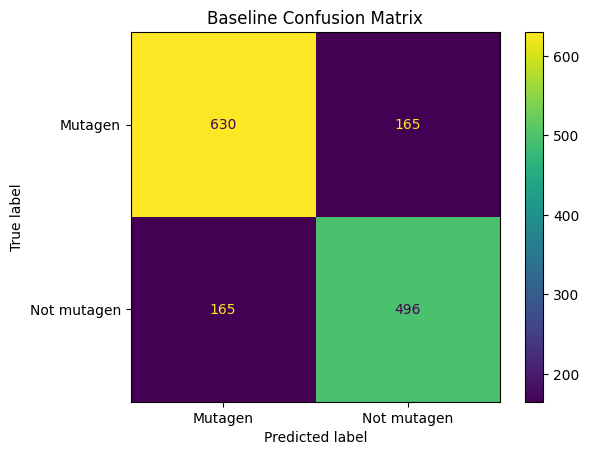

In [48]:
ConfusionMatrixDisplay.from_estimator(dtc_default, X_test, y_test)
plt.title("Baseline Confusion Matrix")
plt.show()

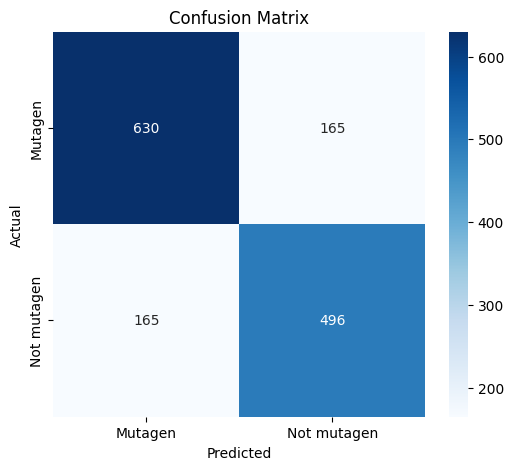

In [69]:
cm_dtc = confusion_matrix(y_test, dtc_y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm_dtc, annot=True, fmt="d",
            xticklabels=dtc_default.classes_,
            yticklabels=dtc_default.classes_,
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### GradientBoostingClassifier

In [131]:

clf = GradientBoostingClassifier(n_estimators=100, learning_rate=1.0,max_depth=1, random_state=42).fit(X_train, y_train)
clf.score(X_test, y_test)



0.7664835164835165

In [106]:
clf_y_pred = clf.predict(X_test) # based on the probability (threshold 50%)
clf_y_proba = clf.predict_proba(X_test)[:, 1] # the probabilities for a positive (needed for the ROC-AUC score)

clf_y_train_pred = clf.predict(X_train)

In [109]:
clf_accuracy=accuracy_score(y_test, clf_y_pred)
clf_roc_auc= roc_auc_score(y_test, clf_y_proba)
clf_train_accuracy=accuracy_score(y_train, clf_y_train_pred)
print("Baseline Accuracy:", clf_accuracy)
print("Baseline ROC-AUC score:", clf_roc_auc)
print("Accuracy on training set:", clf_train_accuracy)

Baseline Accuracy: 0.7664835164835165
Baseline ROC-AUC score: 0.834238194464267
Accuracy on training set: 0.807110958433528


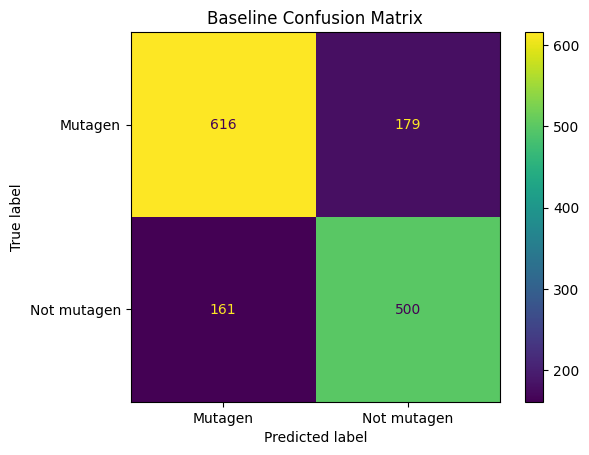

In [90]:
ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test)
plt.title("Baseline Confusion Matrix")
plt.show()

### KNeighborsClassifier

In [133]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [134]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [95]:
knn_y_test_pred = knn.predict(X_test_scaled)
knn_y_train_pred = knn.predict(X_train_scaled)

knn_y_proba = knn.predict_proba(X_test)[:, 1] # the probabilities for a positive (needed for the ROC-AUC score)

In [111]:
knn_accuracy=accuracy_score(y_test, knn_y_test_pred)
knn_roc_auc= roc_auc_score(y_test, knn_y_proba)
knn_train_accuracy = accuracy_score(y_train, knn_y_train_pred)
print("Baseline Accuracy:", knn_accuracy)
print("Baseline ROC-AUC score:", knn_roc_auc)
print("Accuracy on training set:", knn_train_accuracy)


Baseline Accuracy: 0.7465659340659341
Baseline ROC-AUC score: 0.5984138764403086
Accuracy on training set: 0.8447268979732051


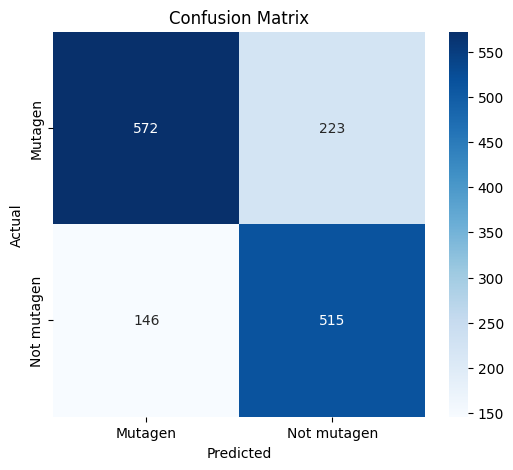

In [86]:
knn_cm = confusion_matrix(y_test, knn_y_test_pred)

plt.figure(figsize=(6,5))
sns.heatmap(knn_cm, annot=True, fmt="d",
            xticklabels=knn.classes_,
            yticklabels=knn.classes_,
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()



### RF

In [114]:
rf_default = RandomForestClassifier(n_estimators=200, random_state=42)

rf_default.fit(X_train, y_train)



,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [115]:
rf_y_pred = rf_default.predict(X_test) # based on the probability (threshold 50%)
rf_y_proba = rf_default.predict_proba(X_test)[:, 1] # the probabilities for a positive (needed for the ROC-AUC score)


rf_y_train_pred = rf_default.predict(X_train)

In [119]:
rf_accuracy = accuracy_score(y_test, rf_y_pred)
rf_roc_auc = roc_auc_score(y_test, rf_y_proba)
rf_train_accuracy = accuracy_score(y_train, rf_y_train_pred)

print("Baseline Accuracy:", rf_accuracy)
print("Baseline ROC-AUC score:", rf_roc_auc)
print("Accuracy on test set:", rf_train_accuracy)

Baseline Accuracy: 0.8324175824175825
Baseline ROC-AUC score: 0.9115881216757533
Accuracy on test set: 0.9991411885949846


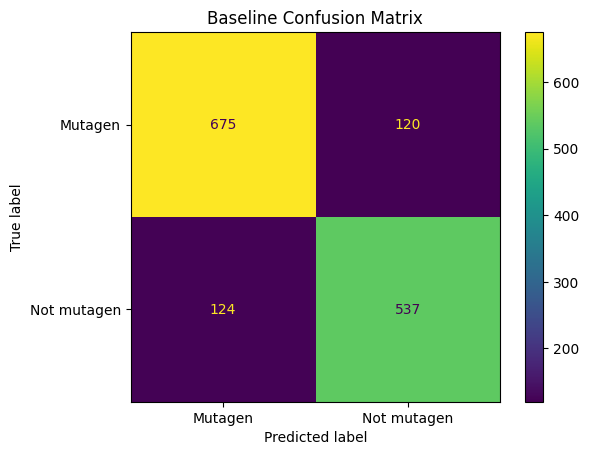

In [75]:
ConfusionMatrixDisplay.from_estimator(rf_default, X_test, y_test)
plt.title("Baseline Confusion Matrix")
plt.show()

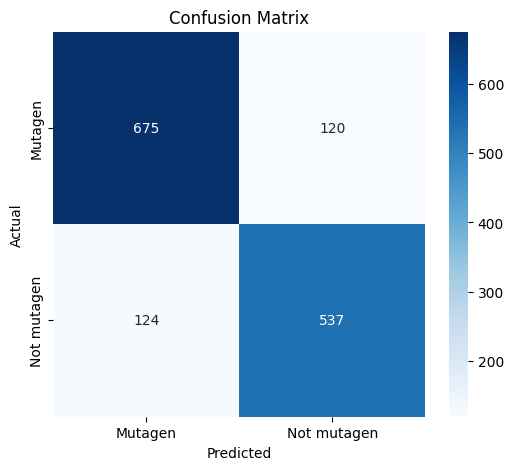

In [76]:
cm_RF = confusion_matrix(y_test, rf_y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm_RF, annot=True, fmt="d",
            xticklabels=rf_default.classes_,
            yticklabels=rf_default.classes_,
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### Comparison

In [130]:
Baseline_Accuracy=[dtc_accuracy,clf_accuracy,knn_accuracy, rf_accuracy]
Baseline_ROC_AUC_score= [dtc_roc_auc, clf_roc_auc,knn_roc_auc, rf_roc_auc]
Accuracy_on_test_set= [dtc_train_accuracy, clf_train_accuracy, knn_train_accuracy, rf_train_accuracy]

dtc_metrics=[dtc_accuracy, dtc_roc_auc, dtc_train_accuracy]
clf_metrics=[clf_accuracy, clf_roc_auc, clf_train_accuracy]
knn_metrics=[knn_accuracy, knn_roc_auc, knn_train_accuracy]
rf_metrics=[rf_accuracy, rf_roc_auc, rf_train_accuracy]

metrics=[Baseline_Accuracy, Baseline_ROC_AUC_score, Accuracy_on_test_set]
df_metrics = pd.DataFrame(metrics, index=["Baseline Accuracy:", "Baseline ROC-AUC score:", "Accuracy on test set:"],columns=["dtc", "clf", "knn", "rf"])
display(df_metrics)



,dtc,clf,knn,rf
Baseline Accuracy:,0.773352,0.766484,0.746566,0.832418
Baseline ROC-AUC score:,0.771887,0.834238,0.598414,0.911588
Accuracy on test set:,0.999141,0.807111,0.844727,0.999141


## 4. Conclusion and discussion
- Which model performed the best?
- Which was the most time efficient?
- Which model showed the wors overfitting?
- Why does ensemble learning outperform a single tree?
- Why does KNN perform well in high-dimensional fingerprint space?
- What does ROC-AUC tell us that accuracy does not?

RandomForestClassifier performed the best overall, even though it did not have the best accuarcy on the test set. KNN was the fastest ("0 sec"). 

Worst overfitting: DecisionTreeClassifier, difference of about 20% between training and test predicitons. 
Ensamble: trains two weak models with high bias and veriance and then combine to a robost model, single tree can get lost if it takes the wrong turning early on. 

KNN high dim: KNN distance based, in fingerprint space structurally similar molecules cluster naturally, so can be better divided. 


AUC: how much data were correctly classified
